In [5]:
  # Import pandas first

df = pd.read_csv("HistoricalQuotes.csv")

print("\n")
print("=" * 70)
print("GRU FORECASTING PROJECT")
print("=" * 70)

print("Dataset Loaded Successfully")

print("Dataset Shape :", df.shape)



GRU FORECASTING PROJECT
Dataset Loaded Successfully
Dataset Shape : (2518, 6)


In [7]:
print("\n")
print("=" * 70)
print("FIRST 5 RECORDS")
print("=" * 70)

display(
    df.head()
)



FIRST 5 RECORDS


,Date,Close/Last,Volume,Open,High,Low
0,02/28/2020,$273.36,106721200,$257.26,$278.41,$256.37
1,02/27/2020,$273.52,80151380,$281.1,$286,$272.96
2,02/26/2020,$292.65,49678430,$286.53,$297.88,$286.5
3,02/25/2020,$288.08,57668360,$300.95,$302.53,$286.13
4,02/24/2020,$298.18,55548830,$297.26,$304.18,$289.23


In [8]:
df.columns = df.columns.str.strip()


print("\n")
print("=" * 70)
print("COLUMN NAMES")
print("=" * 70)

print(
    df.columns.tolist()
)



COLUMN NAMES
['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low']


In [9]:
required_columns = [
    "Date",
    "Close/Last",
    "Volume",
    "Open",
    "High",
    "Low"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]


if len(missing_columns) > 0:

    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


print("\n")
print("=" * 70)
print("REQUIRED COLUMNS VERIFIED")
print("=" * 70)

print("All required columns are available.")




REQUIRED COLUMNS VERIFIED
All required columns are available.


In [10]:
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)


In [11]:
price_columns = [
    "Close/Last",
    "Open",
    "High",
    "Low"
]


for column in price_columns:

    df[column] = (

        df[column]
        .astype(str)
        .str.replace(
            "$",
            "",
            regex=False
        )
        .str.replace(
            ",",
            "",
            regex=False
        )
        .str.strip()
        .astype(float)

    )



In [12]:
df["Volume"] = (

    df["Volume"]
    .astype(str)
    .str.replace(
        ",",
        "",
        regex=False
    )
    .str.strip()
    .astype(float)

)

In [13]:
print("\n")
print("=" * 70)
print("CLEANED DATA")
print("=" * 70)

display(
    df.head()
)




CLEANED DATA


,Date,Close/Last,Volume,Open,High,Low
0,2020-02-28,273.36,106721200.0,257.26,278.41,256.37
1,2020-02-27,273.52,80151380.0,281.10,286.00,272.96
2,2020-02-26,292.65,49678430.0,286.53,297.88,286.50
3,2020-02-25,288.08,57668360.0,300.95,302.53,286.13
4,2020-02-24,298.18,55548830.0,297.26,304.18,289.23


In [14]:
print("\n")
print("=" * 70)
print("DATA TYPES")
print("=" * 70)

print(
    df.dtypes
)



DATA TYPES
Date          datetime64[us]
Close/Last           float64
Volume               float64
Open                 float64
High                 float64
Low                  float64
dtype: object


In [15]:
print("\n")
print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

df.info()



DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 2518 entries, 0 to 2517
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        2518 non-null   datetime64[us]
 1   Close/Last  2518 non-null   float64       
 2   Volume      2518 non-null   float64       
 3   Open        2518 non-null   float64       
 4   High        2518 non-null   float64       
 5   Low         2518 non-null   float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 118.2 KB


In [16]:
missing_values = df.isnull().sum()


print("\n")
print("=" * 70)
print("MISSING VALUES")
print("=" * 70)

display(
    missing_values
)




MISSING VALUES


Date          0
Close/Last    0
Volume        0
Open          0
High          0
Low           0
dtype: int64

In [17]:
duplicate_count = df.duplicated().sum()


print("\n")
print("=" * 70)
print("DUPLICATE RECORDS")
print("=" * 70)

print(
    "Duplicate Rows :",
    duplicate_count
)



DUPLICATE RECORDS
Duplicate Rows : 0


In [18]:
df = df.dropna(
    subset=[
        "Date"
    ]
)



In [19]:
df = df.sort_values(
    "Date"
).reset_index(
    drop=True
)


print("\n")
print("=" * 70)
print("CHRONOLOGICAL ORDER")
print("=" * 70)

print("Oldest Records:")

display(
    df.head(3)
)

print("Latest Records:")

display(
    df.tail(3)
)




CHRONOLOGICAL ORDER
Oldest Records:


,Date,Close/Last,Volume,Open,High,Low
0,2010-03-01,29.8557,137312041.0,29.3928,29.9286,29.3500
1,2010-03-02,29.8357,141486282.0,29.9900,30.1186,29.6771
2,2010-03-03,29.9043,92846488.0,29.8486,29.9814,29.7057


Latest Records:


,Date,Close/Last,Volume,Open,High,Low
2515,2020-02-26,292.65,49678430.0,286.53,297.88,286.50
2516,2020-02-27,273.52,80151380.0,281.10,286.00,272.96
2517,2020-02-28,273.36,106721200.0,257.26,278.41,256.37


In [20]:
print("\n")
print("=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)

display(
    df.describe()
)



STATISTICAL SUMMARY


,Date,Close/Last,Volume,Open,High,Low
count,2518,2518.000000,2.518000e+03,2518.000000,2518.000000,2518.000000
mean,2015-02-26 15:01:17.204130,114.769522,7.258009e+07,114.728443,115.766415,113.690582
min,2010-03-01 00:00:00,29.835700,1.136205e+07,29.392800,29.928600,28.464300
25%,2012-08-24 18:00:00,66.822475,3.053026e+07,66.877150,67.475300,66.372950
50%,2015-02-28 12:00:00,101.090000,5.295469e+07,101.115000,102.085000,100.350000
75%,2017-08-27 06:00:00,154.630000,9.861006e+07,154.610000,155.735000,153.325000
max,2020-02-28 00:00:00,327.200000,4.624423e+08,324.740000,327.850000,323.350000
std,NaN,60.662405,5.663113e+07,60.546893,61.134456,60.085105


In [21]:
print("\n")
print("=" * 70)
print("DATE RANGE")
print("=" * 70)

print(
    "Start Date :",
    df["Date"].min()
)

print(
    "End Date   :",
    df["Date"].max()
)



DATE RANGE
Start Date : 2010-03-01 00:00:00
End Date   : 2020-02-28 00:00:00


In [22]:
print("\n")
print("=" * 70)
print("CLOSING PRICE STATISTICS")
print("=" * 70)

print(
    "Minimum Close :",
    round(
        df["Close/Last"].min(),
        2
    )
)

print(
    "Maximum Close :",
    round(
        df["Close/Last"].max(),
        2
    )
)

print(
    "Average Close :",
    round(
        df["Close/Last"].mean(),
        2
    )
)

print(
    "Median Close  :",
    round(
        df["Close/Last"].median(),
        2
    )
)




CLOSING PRICE STATISTICS
Minimum Close : 29.84
Maximum Close : 327.2
Average Close : 114.77
Median Close  : 101.09


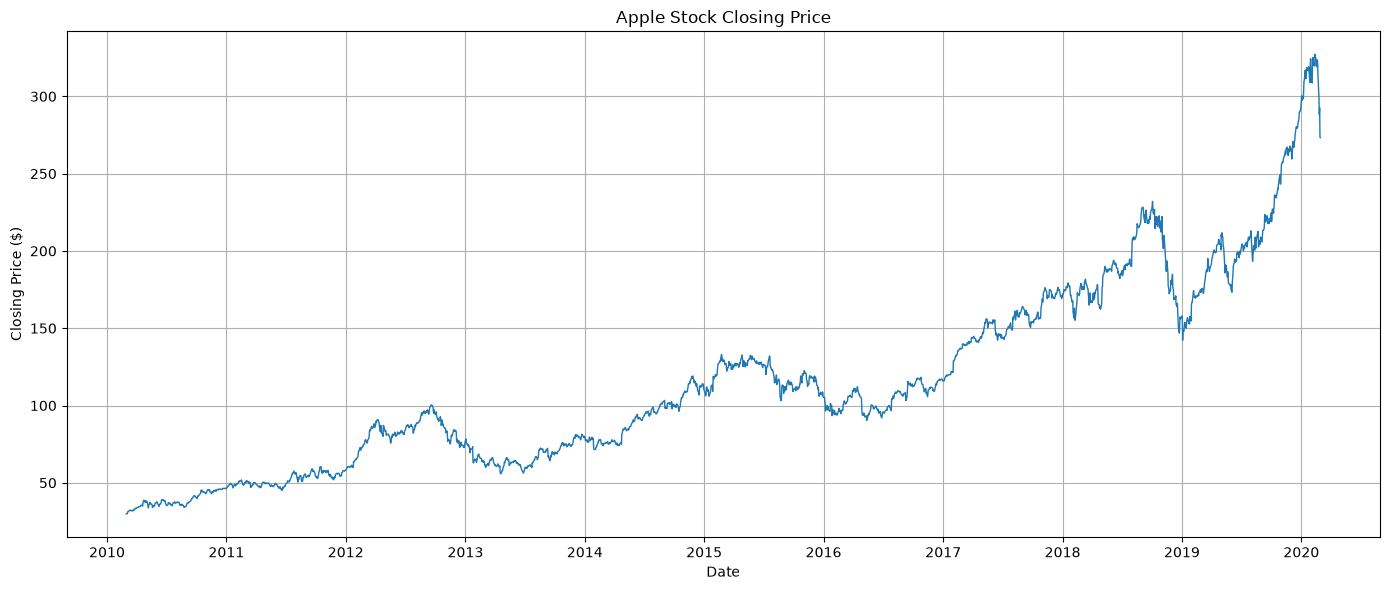

In [26]:
import matplotlib.pyplot as plt
plt.figure(
    figsize=(14, 6)
)

plt.plot(
    df["Date"],
    df["Close/Last"],
    linewidth=1
)

plt.title(
    "Apple Stock Closing Price"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Closing Price ($)"
)

plt.grid()

plt.tight_layout()

plt.show()


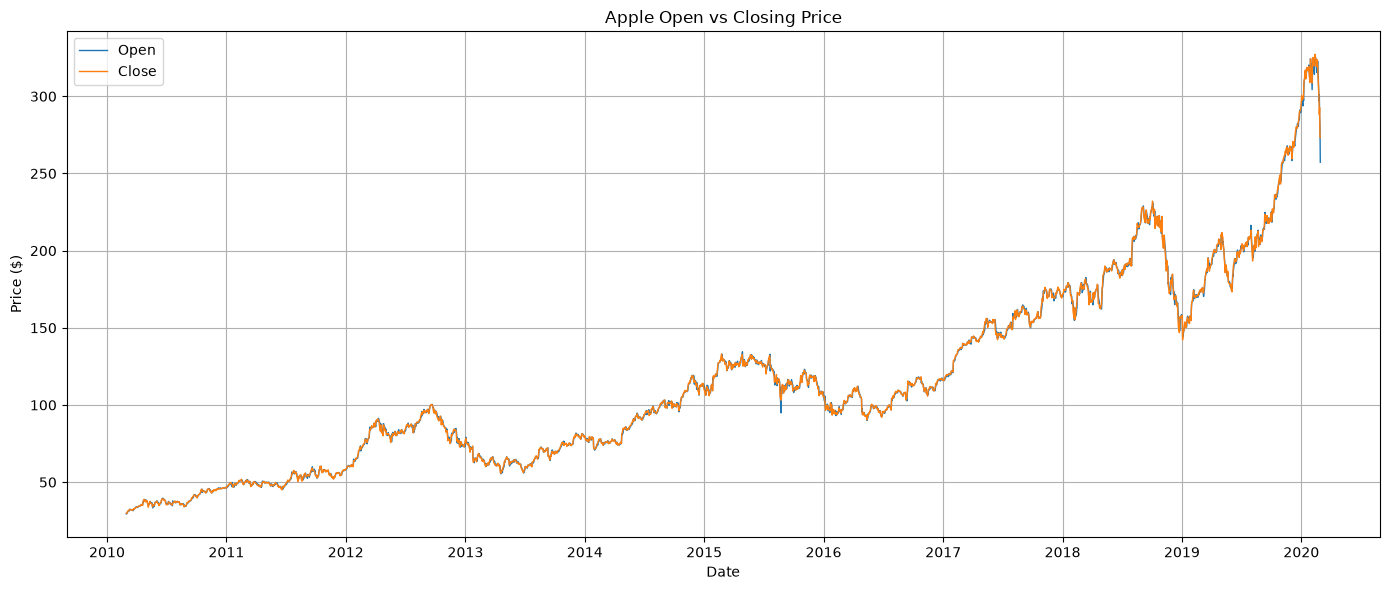

In [27]:
plt.figure(
    figsize=(14, 6)
)

plt.plot(
    df["Date"],
    df["Open"],
    label="Open",
    linewidth=1
)

plt.plot(
    df["Date"],
    df["Close/Last"],
    label="Close",
    linewidth=1
)

plt.title(
    "Apple Open vs Closing Price"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Price ($)"
)

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()


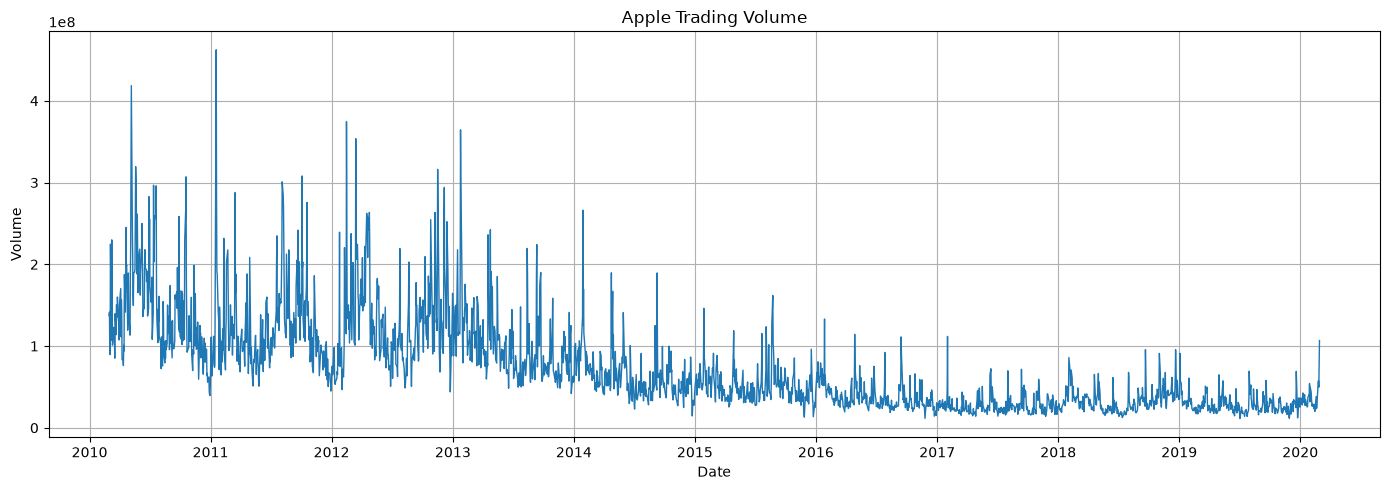

In [28]:
plt.figure(
    figsize=(14, 5)
)

plt.plot(
    df["Date"],
    df["Volume"],
    linewidth=1
)

plt.title(
    "Apple Trading Volume"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Volume"
)

plt.grid()

plt.tight_layout()

plt.show()


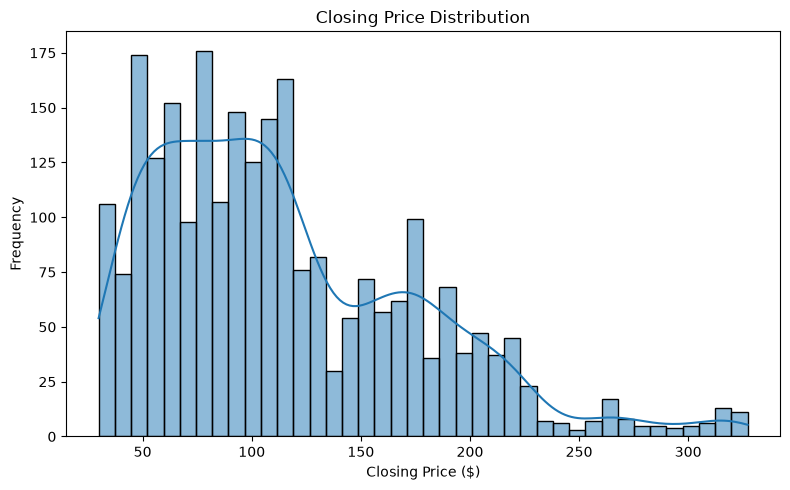

In [30]:
import seaborn as sns
plt.figure(
    figsize=(8, 5)
)

sns.histplot(
    df["Close/Last"],
    bins=40,
    kde=True
)

plt.title(
    "Closing Price Distribution"
)

plt.xlabel(
    "Closing Price ($)"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()

plt.show()

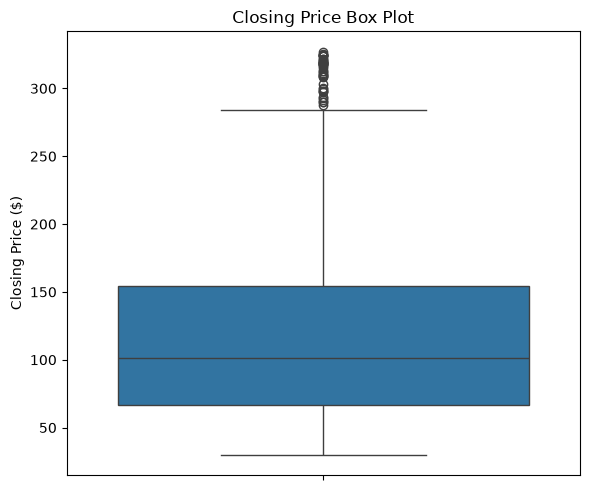

In [31]:
plt.figure(
    figsize=(6, 5)
)

sns.boxplot(
    y=df["Close/Last"]
)

plt.title(
    "Closing Price Box Plot"
)

plt.ylabel(
    "Closing Price ($)"
)

plt.tight_layout()

plt.show()


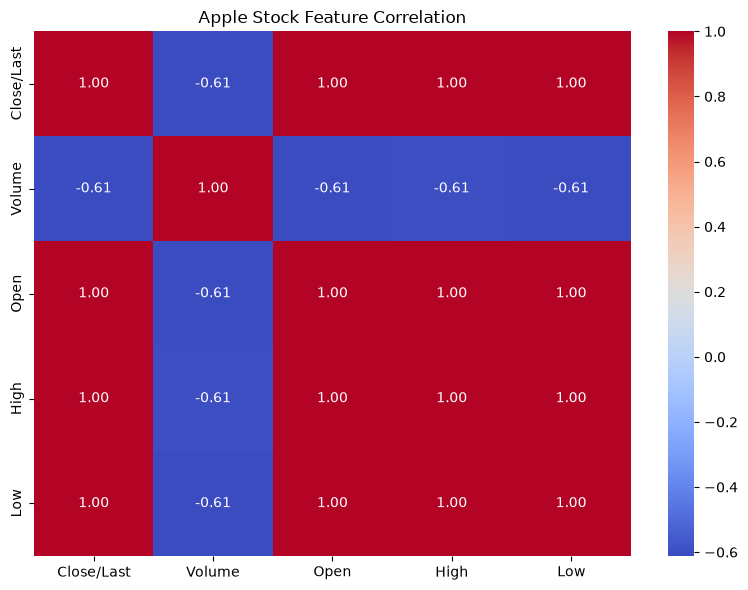

In [32]:
numeric_columns = [
    "Close/Last",
    "Volume",
    "Open",
    "High",
    "Low"
]

correlation_matrix = df[
    numeric_columns
].corr()


plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Apple Stock Feature Correlation"
)

plt.tight_layout()

plt.show()


In [33]:
print("\n")
print("=" * 70)
print("INVALID VALUE CHECK")
print("=" * 70)

print(
    "Negative Close Values :",
    (
        df["Close/Last"] < 0
    ).sum()
)

print(
    "Negative Volume Values:",
    (
        df["Volume"] < 0
    ).sum()
)



INVALID VALUE CHECK
Negative Close Values : 0
Negative Volume Values: 0


In [34]:
summary = pd.DataFrame({

    "Parameter": [

        "Dataset",
        "Problem Type",
        "Total Records",
        "Total Columns",
        "Target Variable",
        "Model",
        "Sequence Length",
        "Training Approach"
    ],

    "Value": [

        "Apple Historical Quotes",
        "Time Series Forecasting",
        len(df),
        len(df.columns),
        "Close/Last",
        "GRU",
        30,
        "Chronological Split"
    ]

})


print("\n")
print("=" * 70)
print("FINAL DATASET SUMMARY")
print("=" * 70)

display(
    summary
)





FINAL DATASET SUMMARY


,Parameter,Value
0,Dataset,Apple Historical Quotes
1,Problem Type,Time Series Forecasting
2,Total Records,2518
3,Total Columns,6
4,Target Variable,Close/Last
5,Model,GRU
6,Sequence Length,30
7,Training Approach,Chronological Split


In [35]:
print("\n")
print("=" * 70)
print("FINAL DATASET CHECK")
print("=" * 70)

print(
    "Rows           :",
    len(df)
)

print(
    "Columns        :",
    len(df.columns)
)

print(
    "Missing Values :",
    df.isnull().sum().sum()
)

print(
    "Duplicate Rows :",
    df.duplicated().sum()
)

print(
    "Start Date     :",
    df["Date"].min()
)

print(
    "End Date       :",
    df["Date"].max()
)

print(
    "Minimum Close  :",
    round(
        df["Close/Last"].min(),
        2
    )
)

print(
    "Maximum Close  :",
    round(
        df["Close/Last"].max(),
        2
    )
)




FINAL DATASET CHECK
Rows           : 2518
Columns        : 6
Missing Values : 0
Duplicate Rows : 0
Start Date     : 2010-03-01 00:00:00
End Date       : 2020-02-28 00:00:00
Minimum Close  : 29.84
Maximum Close  : 327.2


In [36]:
print(
    "Dataset      : Apple Historical Quotes"
)

print(
    "Target       : Close/Last"
)

print(
    "Model        : GRU"
)

print(
    "Sequence     : 30 Trading Days"
)

print(
    "CPU Friendly : YES"
)

print("=" * 70)

Dataset      : Apple Historical Quotes
Target       : Close/Last
Model        : GRU
Sequence     : 30 Trading Days
CPU Friendly : YES


In [37]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

In [38]:
SEQUENCE_LENGTH = 30
TRAIN_RATIO = 0.80
BATCH_SIZE = 16

In [39]:
prices = df["Close/Last"].values.astype(np.float32).reshape(-1, 1)

In [41]:
split = int(len(prices) * TRAIN_RATIO)
train_prices = prices[:split]
test_prices = prices[split:]

In [42]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_prices).astype(np.float32)
test_scaled = scaler.transform(test_prices).astype(np.float32)

In [43]:
def create_sequences(data, length):
    X, y = [], []

    for i in range(len(data) - length):
        X.append(data[i:i + length])
        y.append(data[i + length])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [44]:
X_train, y_train = create_sequences(
    train_scaled,
    SEQUENCE_LENGTH
)

In [45]:
test_input = np.concatenate(
    [train_scaled[-SEQUENCE_LENGTH:], test_scaled]
)

X_test, y_test = create_sequences(
    test_input,
    SEQUENCE_LENGTH
)

In [46]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
).batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
).batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)


In [47]:
print("=" * 60)
print("PART-1B COMPLETED")
print("=" * 60)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)
print("Sequence Length:", SEQUENCE_LENGTH)
print("Batch Size     :", BATCH_SIZE)

print("\nReady for GRU training.")

PART-1B COMPLETED
Training Shape : (1984, 30, 1)
Testing Shape  : (504, 30, 1)
Sequence Length: 30
Batch Size     : 16

Ready for GRU training.


In [48]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [49]:
model = Sequential([
    GRU(
        32,
        activation="tanh",
        input_shape=(SEQUENCE_LENGTH, 1)
    ),
    Dense(16, activation="relu"),
    Dense(1)
])

C:\Users\reddy\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [50]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [51]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_gru_model.keras",
    monitor="val_loss",
    save_best_only=True
)

In [52]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 7.8261e-04 - mae: 0.0223 - val_loss: 0.0153 - val_mae: 0.0830
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0046 - mae: 0.0482 - val_loss: 0.0121 - val_mae: 0.0764
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0022 - mae: 0.0313 - val_loss: 0.0053 - val_mae: 0.0486
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.9291e-04 - mae: 0.0151 - val_loss: 0.0035 - val_mae: 0.0392
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6958e-04 - mae: 0.0097 - val_loss: 0.0031 - val_mae: 0.0375
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.3212e-04 - mae: 0.0084 - val_loss: 0.0032 - val_mae: 0.0379
Epoch 7/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.2555e-04 - mae: 0.0081 - val_loss: 0.0034 - val_mae: 0.0394
Epoch 8/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.2505e-04 - mae: 0.0081 - val_loss: 0.0036 - val_mae: 0.0411


In [53]:
loss, mae = model.evaluate(
    test_dataset,
    verbose=0
)


print("=" * 60)
print("PART-2 COMPLETED")
print("=" * 60)

print("Test Loss :", round(float(loss), 4))
print("Test MAE  :", round(float(mae), 4))


PART-2 COMPLETED
Test Loss : 0.0031
Test MAE  : 0.0375


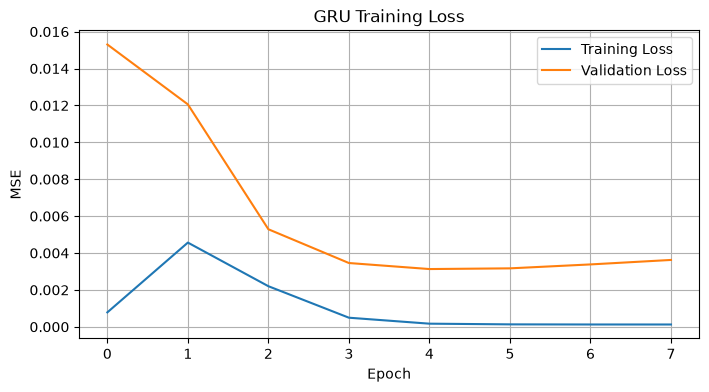

In [54]:
plt.figure(figsize=(8, 4))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("GRU Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")

plt.legend()
plt.grid()
plt.show()

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [56]:
pred_scaled = model.predict(X_test, verbose=0)

In [57]:
predicted = scaler.inverse_transform(pred_scaled)
actual = scaler.inverse_transform(y_test)


In [58]:
mae = mean_absolute_error(actual, predicted)
mse = mean_squared_error(actual, predicted)
rmse = np.sqrt(mse)

print("=" * 60)
print("GRU MODEL PERFORMANCE")
print("=" * 60)

print("MAE  :", round(float(mae), 2))
print("MSE  :", round(float(mse), 2))
print("RMSE :", round(float(rmse), 2))

GRU MODEL PERFORMANCE
MAE  : 5.6
MSE  : 69.89
RMSE : 8.36


In [59]:
results = pd.DataFrame({
    "Actual": actual.flatten(),
    "Predicted": predicted.flatten()
})

display(results.head(10))

,Actual,Predicted
0,178.119995,178.258865
1,175.000000,178.344345
2,176.210007,176.569794
3,176.820023,176.523773
4,176.669998,176.898590
5,175.029999,176.970993
6,176.940002,176.054245
7,179.979996,176.763153
8,181.720001,178.817123
9,179.970001,180.643005


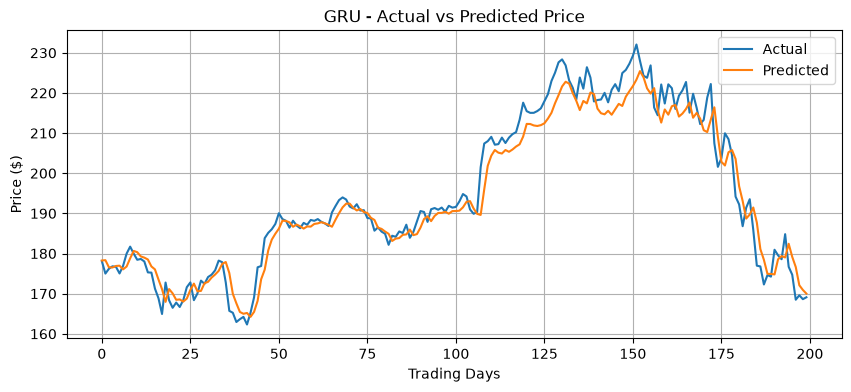

In [60]:
plt.figure(figsize=(10, 4))

plt.plot(
    actual[:200],
    label="Actual"
)

plt.plot(
    predicted[:200],
    label="Predicted"
)

plt.title("GRU - Actual vs Predicted Price")
plt.xlabel("Trading Days")
plt.ylabel("Price ($)")

plt.legend()
plt.grid()
plt.show()

In [61]:
last_sequence = X_test[-1:]

next_scaled = model.predict(
    last_sequence,
    verbose=0
)

next_price = scaler.inverse_transform(
    next_scaled
)[0][0]

print("\n")
print("=" * 60)
print("NEXT DAY FORECAST")
print("=" * 60)

print(
    "Predicted Closing Price : $",
    round(float(next_price), 2)
)




NEXT DAY FORECAST
Predicted Closing Price : $ 265.27


In [62]:
results.to_csv(
    "GRU_Predictions.csv",
    index=False
)

pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE"],
    "Value": [mae, mse, rmse]
}).to_csv(
    "GRU_Metrics.csv",
    index=False
)


print("\n")
print("=" * 60)
print("PROJECT COMPLETED")
print("=" * 60)

print("Model   : best_gru_model.keras")
print("Results : GRU_Predictions.csv")
print("Metrics : GRU_Metrics.csv")
print("Next Day Prediction : $", round(float(next_price), 2))



PROJECT COMPLETED
Model   : best_gru_model.keras
Results : GRU_Predictions.csv
Metrics : GRU_Metrics.csv
Next Day Prediction : $ 265.27
